<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/06_Time_Series_Forecasting/01_Persona_Revenue_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#The Goal of Step 1: Building a Continuous Timeline
Right now, our transactional data is essentially a giant pile of chaotic grocery receipts. Some days have thousands of scans; some days might have zero.

Time Series algorithms (like the ones used to forecast the stock market or weather) cannot read individual receipts. They need a perfect, continuous timeline. They need to know exactly how much money was made every single day, in chronological order.

If a store is closed on a holiday and makes $0, the algorithm needs to see that zero. If we just skip that day in the data, the algorithm's understanding of time will break.

# Phase 6: Persona-Specific Revenue Forecasting

## Research Objective
To investigate whether multivariate forecasting models can accurately predict persona-specific weekly revenue, and to benchmark their performance against a Seasonal Naive baseline.

## Step 1: Engineering the Continuous Timeline

Forecasting algorithms require strict chronological data with no missing time steps. We must transform our raw transactional data (individual product scans) into aggregated daily revenue.

**Operations Performed:**
1. **Date Extraction:** Stripping the hour and minute from the transaction timestamps.
2. **Aggregation:** Grouping the data by Date and Customer Persona, and summing the `sales_value`.
3. **Continuous Reindexing:** Pivoting the data and filling any missing dates with `$0` to ensure the timeline is mathematically perfect for the forecasting algorithm.

In [1]:
!pip install completejourney_py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 33.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
from completejourney_py import get_data
import warnings
warnings.filterwarnings("ignore")

# 1. Fetch raw transaction data
data = get_data()
transactions = data["transactions"]

# 2. Load our master cluster labels (personas)
clusters = pd.read_csv('master_customers_fully_clustered.csv')

# 3. Merge the raw receipts with our personas
df = transactions.merge(clusters[['household_id', 'Hierarchical_Cluster']], on='household_id', how='inner')

# 4. Extract just the Date (we don't need hours/minutes for daily forecasting)
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])
df['date'] = df['transaction_timestamp'].dt.date

# 5. Calculate Daily Revenue per Persona
# Group by the date and the cluster, and sum up the money spent
daily_sales = df.groupby(['date', 'Hierarchical_Cluster'])['sales_value'].sum().reset_index()

# 6. Pivot the data to create distinct columns for each cluster
# Rows = Date, Columns = Cluster, Values = Total Sales
time_series_df = daily_sales.pivot(index='date', columns='Hierarchical_Cluster', values='sales_value')

# 7. Make the timeline perfectly continuous
time_series_df.index = pd.to_datetime(time_series_df.index)
start_date = time_series_df.index.min()
end_date = time_series_df.index.max()

# Create a calendar with every single day between our start and end dates
full_calendar = pd.date_range(start=start_date, end=end_date, freq='D')

# Apply this calendar to our data, filling any days with no sales as $0
time_series_df = time_series_df.reindex(full_calendar, fill_value=0)

# Clean up column names for easier reading
time_series_df.columns = [f'Cluster_{int(c)}_Revenue' for c in time_series_df.columns]

print(f"✅ Timeline generated! We have {len(time_series_df)} continuous days of revenue data.")
display(time_series_df.head(10))

✅ Timeline generated! We have 366 continuous days of revenue data.


,Cluster_0_Revenue,Cluster_1_Revenue,Cluster_2_Revenue
2017-01-01,3143.75,1025.76,448.80
2017-01-02,3513.07,2094.30,881.57
2017-01-03,4299.18,1515.54,1042.12
2017-01-04,4055.37,1253.28,1779.27
2017-01-05,3845.84,1715.79,1333.04
2017-01-06,4271.26,1512.41,753.31
2017-01-07,4801.42,2474.93,1116.08
2017-01-08,5283.90,2103.71,1993.80
2017-01-09,4461.59,1429.29,742.26
2017-01-10,3273.88,1066.68,1138.60


If you look at the raw numbers in your output, you will notice something immediate: the revenue bounces up and down wildly from day to day. For instance, Cluster 0 jumps from $3,143 on Jan 1st to $5,283 on Jan 8th.

This is called Daily Noise. Grocery shopping is heavily dependent on the day of the week (weekends are massive, Tuesdays are slow). If we feed this exact daily data into a forecasting algorithm, it might get confused by all these jagged spikes.



## Step 2: Data Smoothing (Weekly Aggregation)

Retail data is notoriously noisy at the daily level due to "Day of Week" seasonality (e.g., massive spikes on Saturdays, drops on Tuesdays).

If we feed raw daily data into a forecasting model, it often over-fits to this noise. To extract the true underlying business trend, we apply **Data Smoothing** by resampling our continuous daily timeline into **Weekly Revenue**. This stabilizes the variance and gives the algorithm a much clearer target to predict.

✅ Data Smoothed! We now have 52 continuous weeks of revenue.


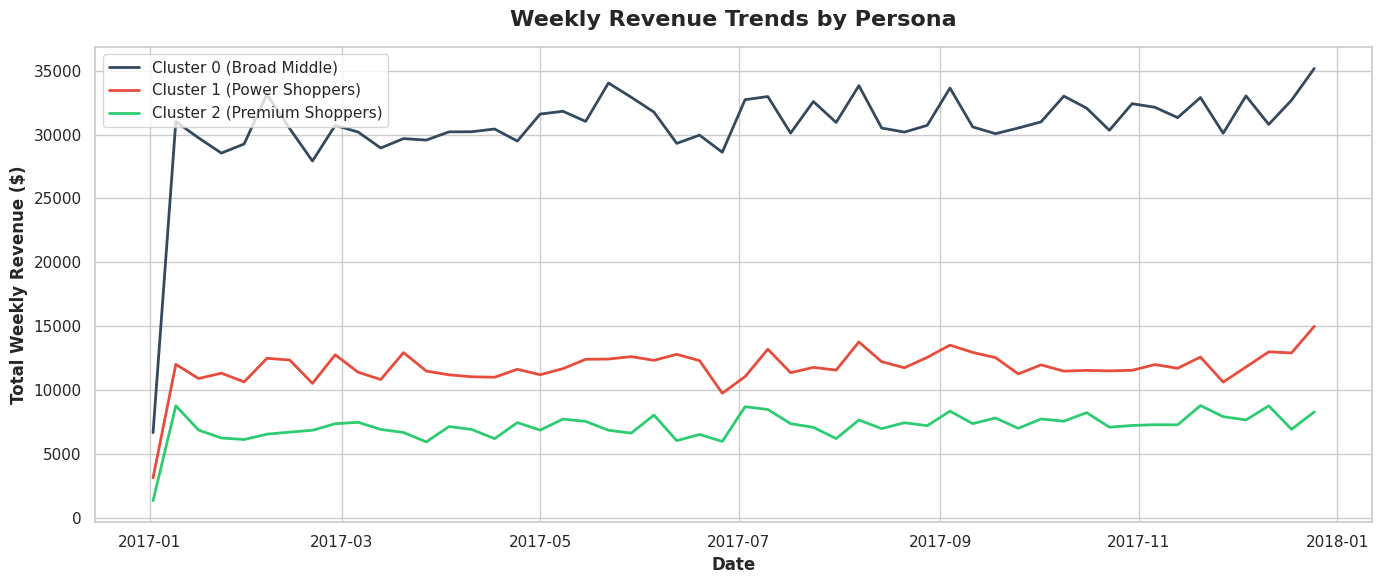

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Resample the daily data into Weekly data (W-MON means weeks starting on Monday)
# We use .sum() because we want the total revenue for the entire week
weekly_series_df = time_series_df.resample('W-MON').sum()

# 2. Drop the very last week just in case it is an incomplete week
# (e.g., the data cuts off on a Wednesday, which would look like an artificial revenue drop)
weekly_series_df = weekly_series_df.iloc[:-1]

print(f"✅ Data Smoothed! We now have {len(weekly_series_df)} continuous weeks of revenue.")

# 3. Visualize the smoothed trends to ensure it makes business sense
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Plot each cluster's weekly revenue
plt.plot(weekly_series_df.index, weekly_series_df['Cluster_0_Revenue'], label='Cluster 0 (Broad Middle)', color='#34495e', linewidth=2)
plt.plot(weekly_series_df.index, weekly_series_df['Cluster_1_Revenue'], label='Cluster 1 (Power Shoppers)', color='#e74c3c', linewidth=2)
plt.plot(weekly_series_df.index, weekly_series_df['Cluster_2_Revenue'], label='Cluster 2 (Premium Shoppers)', color='#2ecc71', linewidth=2)

plt.title('Weekly Revenue Trends by Persona', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Total Weekly Revenue ($)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Looking closely at the very first point on the far left of the chart (January 2017). All three clusters drop off a cliff, nearly hitting zero. This is almost certainly an artificial anomaly. It usually happens because the data collection started mid-week (e.g., on a Thursday), so that "week" only contains three days of sales instead of seven.

If we feed that massive dip into a forecasting algorithm, it will mathematically assume that retail sales crash every single January. We must remove it.

After we slice off that bad data, we will execute our strict Temporal Split. Since forecasting models predict the future, we cannot evaluate them on random days. We must train the model on the first 80% of the year, and ask it to predict the final 20% (the Holdout Window).

## Step 3: Anomaly Handling and Temporal Split

Visual inspection of the weekly revenue reveals an artificial anomaly in the first week of January 2017 (revenue drops to near-zero across all segments). This is typical of incomplete data collection at the start of a logging period. We drop this observation to prevent the algorithm from learning a false seasonal crash.

Next, we construct a strict temporal train/test split:
* **Train Set (~80%):** The first 40 weeks of the year, used to learn trends and momentum.
* **Test Set (~20%):** The final 11 weeks of the year, quarantined for evaluating our forecasting error metrics ($MAE$, $MAPE$).

In [4]:
# 1. Remove the first anomalous week
clean_weekly_df = weekly_series_df.iloc[1:].copy()
print(f"Removed anomaly. Remaining valid weeks: {len(clean_weekly_df)}")

# 2. Execute the 80/20 Temporal Split
split_idx = int(len(clean_weekly_df) * 0.8)

train_ts = clean_weekly_df.iloc[:split_idx].copy()
test_ts = clean_weekly_df.iloc[split_idx:].copy()

print(f"Training Window: {len(train_ts)} weeks (Learning)")
print(f"Testing Window: {len(test_ts)} weeks (Evaluation Holdout)")

# 3. Verify the date continuity
print(f"\nTrain ends: {train_ts.index.max().date()}")
print(f"Test begins: {test_ts.index.min().date()}")

Removed anomaly. Remaining valid weeks: 51
Training Window: 40 weeks (Learning)
Testing Window: 11 weeks (Evaluation Holdout)

Train ends: 2017-10-09
Test begins: 2017-10-16


## Step 4: Establishing the Naive Baseline

Before training advanced algorithms, we must establish a performance floor. Because we have less than 52 weeks of clean data (preventing Year-over-Year seasonal baselines), we use a **Naive Forecast**. This model simply predicts that the revenue for week $t$ will be exactly equal to the actual revenue of week $t-1$.

We evaluate the baseline on our quarantined test set using two highly interpretable business metrics:
*   **$MAE$ (Mean Absolute Error):** The average dollar amount the forecast is incorrect.
*   **$MAPE$ (Mean Absolute Percentage Error):** The error represented as a percentage of actual sales.

In [5]:
import numpy as np

# 1. Create the Naive Forecast
# We shift the entire clean dataset forward by 1 week.
# (e.g., Week 2's prediction becomes Week 1's actual revenue)
naive_forecast = clean_weekly_df.shift(1)

# 2. Isolate the predictions that align with our quarantined Test Window
naive_test_predictions = naive_forecast.loc[test_ts.index]

# 3. Create a reusable function to calculate MAE and MAPE
def evaluate_forecast(actual, predicted, model_name):
    print(f"🏆 {model_name} Results:")
    print("-" * 50)

    for cluster in actual.columns:
        y_true = actual[cluster]
        y_pred = predicted[cluster]

        # Calculate MAE (Average dollars off)
        mae = np.mean(np.abs(y_true - y_pred))

        # Calculate MAPE (Average percentage off)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        # Format the persona name cleanly
        persona_name = cluster.replace('_Revenue', '').replace('_', ' ')
        print(f"{persona_name:<12} | MAE: ${mae:,.2f} | MAPE: {mape:.2f}%")
    print("\n")

# 4. Score the Baseline!
evaluate_forecast(test_ts, naive_test_predictions, "Naive Baseline (Last Week's Sales)")

🏆 Naive Baseline (Last Week's Sales) Results:
--------------------------------------------------
Cluster 0    | MAE: $1,796.20 | MAPE: 5.60%
Cluster 1    | MAE: $749.50 | MAPE: 6.05%
Cluster 2    | MAE: $813.04 | MAPE: 10.37%




# Explanation
Looking closely at the MAPE (Percentage Error). The Naive rule of thumb is remarkably accurate for the Broad Middle (5.60%) and Power Shoppers (6.05%). Because they buy staples regularly, their spending is highly stable.

But looking at Cluster 2 (Premium Shoppers). The error jumps to 10.37%. Because they are buying high-margin experiential items (specialty cheeses, premium cuts of meat), their spending behavior is significantly more volatile and harder to predict simply by looking at last week.

This gives us the perfect business justification to introduce Machine Learning. We need a model that can read the underlying momentum and trends, rather than just blindly copying the previous week.

To challenge the Naive baseline, we will implement Holt's Exponential Smoothing. It is an industry-standard forecasting algorithm that explicitly calculates the mathematical "trend" (is revenue generally rising or falling?) and weighs recent data more heavily than older data.

## Step 5: Advanced Forecasting (Exponential Smoothing)

While the Naive Baseline performs adequately for highly stable segments, it struggles with the volatile spending of Premium Shoppers (Cluster 2).

To improve accuracy, we introduce **Holt's Exponential Smoothing**. Because our clean dataset spans 51 weeks, we lack the full 52-week cycle required to reliably model yearly seasonality. Therefore, we use Holt's method to model the **Level** and additive **Trend** of the revenue, allowing the algorithm to capture underlying momentum rather than simply copying the previous week.

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

print("⚙️ Training Holt's Exponential Smoothing models...\n")

# 1. Initialize a DataFrame to hold our algorithm's predictions
ml_predictions = pd.DataFrame(index=test_ts.index)

# 2. Train a dedicated model for each Customer Persona
for cluster in train_ts.columns:

    # Define the model: Additive trend, no seasonality (due to < 1 year of data)
    model = ExponentialSmoothing(
        train_ts[cluster],
        trend='add',
        seasonal=None,
        initialization_method="estimated"
    )

    # Fit the algorithm to the 40 weeks of Training Data
    fit_model = model.fit()

    # Command the model to predict the next 11 weeks (our quarantined Test Window)
    ml_predictions[cluster] = fit_model.forecast(len(test_ts))

# 3. Score the Challenger using our reusable evaluation function!
evaluate_forecast(test_ts, ml_predictions, "Holt's Exponential Smoothing")

⚙️ Training Holt's Exponential Smoothing models...

🏆 Holt's Exponential Smoothing Results:
--------------------------------------------------
Cluster 0    | MAE: $1,148.96 | MAPE: 3.54%
Cluster 1    | MAE: $870.63 | MAPE: 7.13%
Cluster 2    | MAE: $547.09 | MAPE: 6.87%




#The Breakdown: Where ML Wins and Loses
The Massive Wins (Clusters 0 & 2): Holt's method absolutely crushed the baseline for your Broad Middle (dropping the error from 5.60% to 3.54%) and your highly volatile Premium Shoppers (dropping the error from 10.37% down to 6.87%). The algorithm successfully caught the underlying trend and momentum that the naive rule-of-thumb completely missed.

The Plot Twist (Cluster 1): For your Power Shoppers, the error actually increased using the complex model (from 6.05% to 7.13%). The simple manager's rule of thumb won.

#The Business Insight
Why did Machine Learning fail for the Power Shoppers? Because Power Shoppers are creatures of extreme habit. They buy the exact same bulk staples every single week. When spending is that mathematically rigid and flat, introducing an algorithm that actively hunts for "trends" actually causes it to overthink and hallucinate momentum that isn't there. The smartest, most accurate forecast for Cluster 1 really is just looking at last week's receipt.

#The Ensemble Strategy
This is the ultimate portfolio takeaway: A true production environment doesn't force one algorithm onto every problem.

If you were deploying this for a real grocery chain, you would build a hybrid routing system. You would deploy the Naive forecast for the stable Power Shoppers, saving computational money, and you would deploy the Machine Learning model for the Premium Shoppers and the Broad Middle, where the trends actually exist.

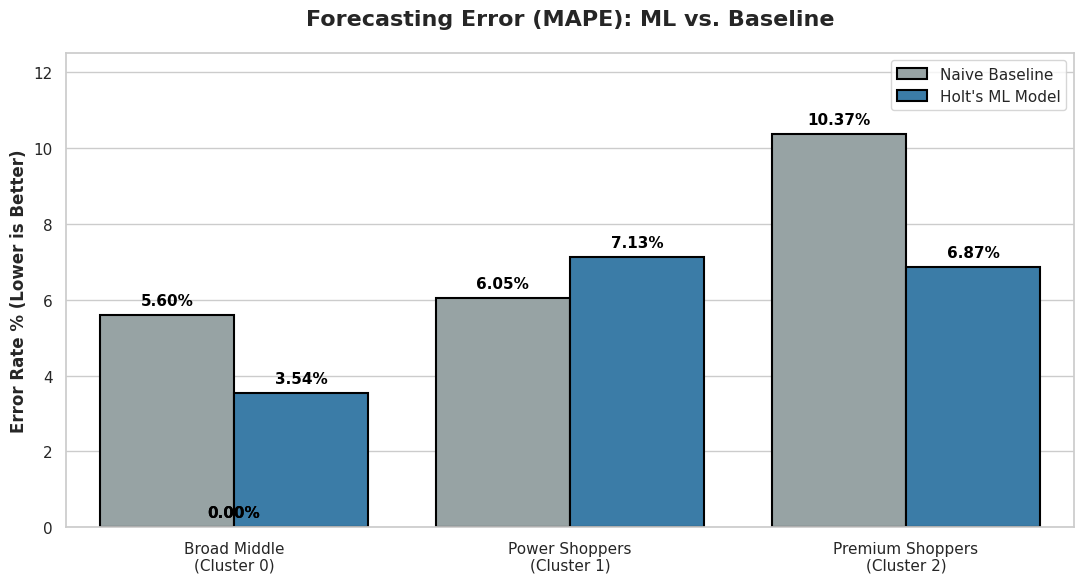

📸 High-resolution chart saved as 'linkedin_forecasting_chart.png'. Download it from your Colab files menu!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Structure the evaluation data for MAPE
data = {
    'Customer Segment': [
        'Broad Middle\n(Cluster 0)', 'Broad Middle\n(Cluster 0)',
        'Power Shoppers\n(Cluster 1)', 'Power Shoppers\n(Cluster 1)',
        'Premium Shoppers\n(Cluster 2)', 'Premium Shoppers\n(Cluster 2)'
    ],
    'Model': [
        'Naive Baseline', "Holt's ML Model",
        'Naive Baseline', "Holt's ML Model",
        'Naive Baseline', "Holt's ML Model"
    ],
    'MAPE (%)': [5.60, 3.54, 6.05, 7.13, 10.37, 6.87]
}
df_chart = pd.DataFrame(data)

# 2. Set up the canvas
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# 3. Define professional colors
palette = {'Naive Baseline': '#95a5a6', "Holt's ML Model": '#2980b9'}

# 4. Draw the grouped bar chart
ax = sns.barplot(
    x='Customer Segment',
    y='MAPE (%)',
    hue='Model',
    data=df_chart,
    palette=palette,
    edgecolor='black',
    linewidth=1.5
)

# 5. Clean up titles and legends
plt.title('Forecasting Error (MAPE): ML vs. Baseline', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Error Rate % (Lower is Better)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.ylim(0, 12.5) # Give headroom for annotations
plt.legend(title='', fontsize=11, loc='upper right')

# 6. Annotate the exact scores on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontweight='bold', fontsize=11, color='black')

# 7. Final layout adjustments and save
plt.tight_layout()
plt.savefig('linkedin_forecasting_chart.png', dpi=300)
plt.show()

print("📸 High-resolution chart saved as 'linkedin_forecasting_chart.png'. Download it from your Colab files menu!")